# v4 — Multi-Head Attention

This builds directly on **v3**. Steps 1–7 below carry over as-is.

What's new:

1. A new `MultiHeadAttention` module: runs several `Head`s in parallel (each with its own learned query/key/value projections) and concatenates their outputs. This lets the model attend to different positions for different reasons at the same time, instead of being limited to a single attention pattern.
2. `BigramLanguageModel.att_head` is now `MultiHeadAttention(8, emb_size // 8)` instead of a single `Head(emb_size)` — note the per-head size shrinks so the concatenated output still has dimension `emb_size`.

## 1. Imports

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

## 2. Hyperparameters

In [ ]:
# emb_size = 32        # embedding size for each token
# batch_size = 32      # how many independent sequences will we process in parallel?
# block_size = 8       # what is the maximum context length for predictions?
# max_iters = 10000    # maximum number of iterations for training
# eval_interval = 500  # interval for evaluating the model
# learning_rate = 1e-3 # learning rate for training
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# eval_iters = 200     # number of iterations for evaluation
# seed = 42            # seed for reproducibility

# torch.manual_seed(seed)

In [2]:
# Sabine's version of the above block that does hardware detection (that way on Mac it uses GPU if available rather than CPU default)
# Detect best available device (CUDA>MPS>CPU) and set DataLoader workers accordingly
import os

emb_size = 32        # embedding size for each token
batch_size = 32      # how many independent sequences will we process in parallel?
block_size = 8       # what is the maximum context length for predictions?
max_iters = 10000    # maximum number of iterations for training
eval_interval = 500  # interval for evaluating the model
learning_rate = 1e-3 # learning rate for training
eval_iters = 200     # number of iterations for evaluation
seed = 42            # seed for reproducibility

if torch.cuda.is_available():
    device = torch.device("cuda")
    total_cores = os.cpu_count()
    NUM_WORKERS = min(8, max(1, total_cores - 2))

elif torch.backends.mps.is_available():
    device = torch.device("mps")
    NUM_WORKERS = 0  # MPS + multiprocessing can hang

else:
    device = torch.device("cpu")
    NUM_WORKERS = 0

print(f"Using device: {device}")
torch.manual_seed(seed)

Using device: cuda


## 3. Load the dataset

In [3]:
with open('./data/harry_potter.txt', encoding='utf-8') as f:
    text = f.read()

print(f"length of dataset in characters: {len(text)}")
print(text[:500])

length of dataset in characters: 5991293
THE BOY WHO LIVED Mr and Mrs Dursley of number four Privet Drive were proud to say that they were perfectly normal thank you very much .They were the last people youd expect to be involved in anything strange or mysterious because they just didnt hold with such nonsense .Mr Dursley was the director of a firm called Grunnings which made drills .He was a big beefy man with hardly any neck although he did have a very large mustache .Mrs Dursley was thin and blonde and had nearly twice the usual amo


## 4. Tokenization: characters as tokens

In [4]:
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)

 !.0123456789?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz~‘•■□
71


In [5]:
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

print(encode("Hello there!"))
print(decode(encode("Hello there!")))

[21, 44, 51, 51, 54, 0, 59, 47, 44, 57, 44, 1]
Hello there!


## 5. Train / validation split

In [6]:
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

print(data.shape, data.dtype)
print(data[:100])

torch.Size([5991293]) torch.int64
tensor([33, 21, 18,  0, 15, 28, 38,  0, 36, 21, 28,  0, 25, 22, 35, 18, 17,  0,
        26, 57,  0, 40, 53, 43,  0, 26, 57, 58,  0, 17, 60, 57, 58, 51, 44, 64,
         0, 54, 45,  0, 53, 60, 52, 41, 44, 57,  0, 45, 54, 60, 57,  0, 29, 57,
        48, 61, 44, 59,  0, 17, 57, 48, 61, 44,  0, 62, 44, 57, 44,  0, 55, 57,
        54, 60, 43,  0, 59, 54,  0, 58, 40, 64,  0, 59, 47, 40, 59,  0, 59, 47,
        44, 64,  0, 62, 44, 57, 44,  0, 55, 44])


## 6. Batching

In [7]:
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

In [8]:
xb, yb = get_batch('train')
print('inputs:')
print(xb.shape)
print(xb)
print('targets:')
print(yb.shape)
print(yb)

inputs:
torch.Size([32, 8])
tensor([[54, 60, 57,  0, 52, 54, 59, 47],
        [ 0, 52, 40, 64,  0, 58, 59, 48],
        [44, 58, 58, 54, 57,  0, 15, 51],
        [58, 40, 48, 43,  0, 19, 44, 44],
        [58, 59, 60, 43, 44, 53, 59, 58],
        [57, 40, 48, 59,  0, 58, 62, 60],
        [ 0, 40, 42, 42, 54, 52, 55, 40],
        [ 0, 40, 58,  0, 47, 44,  0, 43],
        [40, 50, 48, 53, 46,  0, 54, 60],
        [48, 58,  0, 48, 53,  0, 45, 40],
        [51, 40, 55,  0, 55, 60, 57, 57],
        [59,  0, 47, 48, 58,  0, 55, 54],
        [57, 44,  0, 47, 40, 43,  0, 59],
        [21, 40, 57, 57, 64,  0,  2, 27],
        [41, 51, 48, 53, 50, 48, 53, 46],
        [ 0, 41, 54, 64,  0, 47, 44, 58],
        [47, 54,  0, 62, 40, 58,  0, 58],
        [44,  0, 58, 52, 48, 57, 50, 44],
        [ 0, 59, 47, 44, 64,  0, 55, 40],
        [40, 57, 57, 64,  0, 51, 40, 60],
        [40, 51, 51, 64,  0, 21, 40, 46],
        [59,  0, 52, 44,  0, 52, 54, 58],
        [47, 40, 61, 44,  0, 43, 57, 40],
      

## 7. Estimating loss

In [9]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

## 8. Self-attention head (recap from v3)

A single attention head — same as v3. `MultiHeadAttention` below will run several of these in parallel.

In [10]:
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key = nn.Linear(emb_size, head_size, bias=False)
        self.query = nn.Linear(emb_size, head_size, bias=False)
        self.value = nn.Linear(emb_size, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        B, T, C = x.shape
        key = self.key(x) # (B,T,H)
        query = self.query(x) # (B,T,H)

        # compute the attention weights
        dot_products = query @ key.transpose(-2,-1) * C**-0.5 # (B,T,H) @ (B,H,T) = (B,T,T) # scale by sqrt(d_k)
        dot_products = dot_products.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mask out the upper triangular part
        weights = F.softmax(dot_products, dim=-1) # (B,T,T) Apply softmax to get the attention weights

        # apply the attention weights to the values
        value = self.value(x) # (B,T,H)
        out = weights @ value # (B,T,T) @ (B,T,H) = (B,T,H)
        return out

## 9. Multi-head attention — what's new

`MultiHeadAttention` owns `num_heads` independent `Head`s (each with its own learned query/key/value projections) and concatenates their outputs along the last dimension. With `num_heads=8` and `head_size=emb_size//8`, the concatenated result lands back at dimension `emb_size`.

**In class:** fill in the parts marked **NEW** below.

In [11]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_heads, head_size):
        super().__init__()
        # NEW: num_heads independent attention heads, run in parallel
        # num_heads specifies the number of independent attention heads (of dimension head), run in parallel
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
            # ModuleList creates a list of different modules in a nice pythonic way (rather than going "self.head1 = Head(head_size)" like 8 times)
                # for _ in range(num_heads) will give us a list of all 8 attention heads ( _ means the index is unused)
                # (for _ in range(num_heads): loop num_heads times)

    def forward(self, x):
        # NEW: concatenate each head's output along the last dimension
        return torch.cat([head(x) for head in self.heads], dim=-1)
            # so, we pass input x through every attention head in self.heads, and then we concatenate in the final axis

## 10. The model — what's new

`BigramLanguageModel` gets one change: `self.att_head` is built from `MultiHeadAttention` instead of a single `Head`. `forward` and `generate` are unchanged.

**In class:** fill in the part marked **NEW** below.

In [14]:
class BigramLanguageModel(nn.Module):

    def __init__(self, vocab_size, emb_size):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(vocab_size, emb_size)
        # we will get to the position embeddings later
        self.position_embedding_table = nn.Embedding(block_size, emb_size)

        # NEW: 8 heads, each of size emb_size // 8, concatenated back up to emb_size
        self.att_head = MultiHeadAttention(num_heads=8, head_size=emb_size//8)
            # we make the head_size = embedding size // 8 to keep things tractable (to avoid the matrix becoming huge)
                # so now each head_size = 4
        self.linear_head = nn.Linear(emb_size, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        # idx and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.att_head(x) # (B,T,C)
        logits = self.linear_head(x)  # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):
        # idx is (B, T) array of indices in the current context
        for _ in range(max_new_tokens):
            # crop idx to the block size
            idx_cond = idx[:, -block_size:] # (B, T)

            # get the predictions
            logits, loss = self(idx_cond)
            # focus only on the last time step
            logits = logits[:, -1, :] # becomes (B, C)
            # apply softmax to get probabilities
            probs = F.softmax(logits, dim=-1) # (B, C)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1) # (B, 1)
            # append sampled index to the running sequence
            idx = torch.cat((idx, idx_next), dim=1) # (B, T+1)
        return idx

In [21]:
BigramLanguageModel(vocab_size, emb_size)

BigramLanguageModel(
  (token_embedding_table): Embedding(71, 32)
  (position_embedding_table): Embedding(8, 32)
  (att_head): MultiHeadAttention(
    (heads): ModuleList(
      (0-7): 8 x Head(
        (key): Linear(in_features=32, out_features=4, bias=False)
        (query): Linear(in_features=32, out_features=4, bias=False)
        (value): Linear(in_features=32, out_features=4, bias=False)
      )
    )
  )
  (linear_head): Linear(in_features=32, out_features=71, bias=True)
)

In [ ]:
from torchinfo import summary

summary(BigramLanguageModel(vocab_size, emb_size), input_size=(batch_size, block_size), dtypes=[torch.long])
    # input_size is (B, T) — a batch of token index sequences
    # dtypes=[torch.long] is needed because token indices are integers,
        # not the default float that torchinfo assumes

Layer (type:depth-idx)                   Output Shape              Param #
BigramLanguageModel                      [32, 8, 71]               --
├─Embedding: 1-1                         [32, 8, 32]               2,272
├─Embedding: 1-2                         [8, 32]                   256
├─MultiHeadAttention: 1-3                [32, 8, 32]               --
│    └─ModuleList: 2-1                   --                        --
│    │    └─Head: 3-1                    [32, 8, 4]                384
│    │    └─Head: 3-2                    [32, 8, 4]                384
│    │    └─Head: 3-3                    [32, 8, 4]                384
│    │    └─Head: 3-4                    [32, 8, 4]                384
│    │    └─Head: 3-5                    [32, 8, 4]                384
│    │    └─Head: 3-6                    [32, 8, 4]                384
│    │    └─Head: 3-7                    [32, 8, 4]                384
│    │    └─Head: 3-8                    [32, 8, 4]                384
├─L

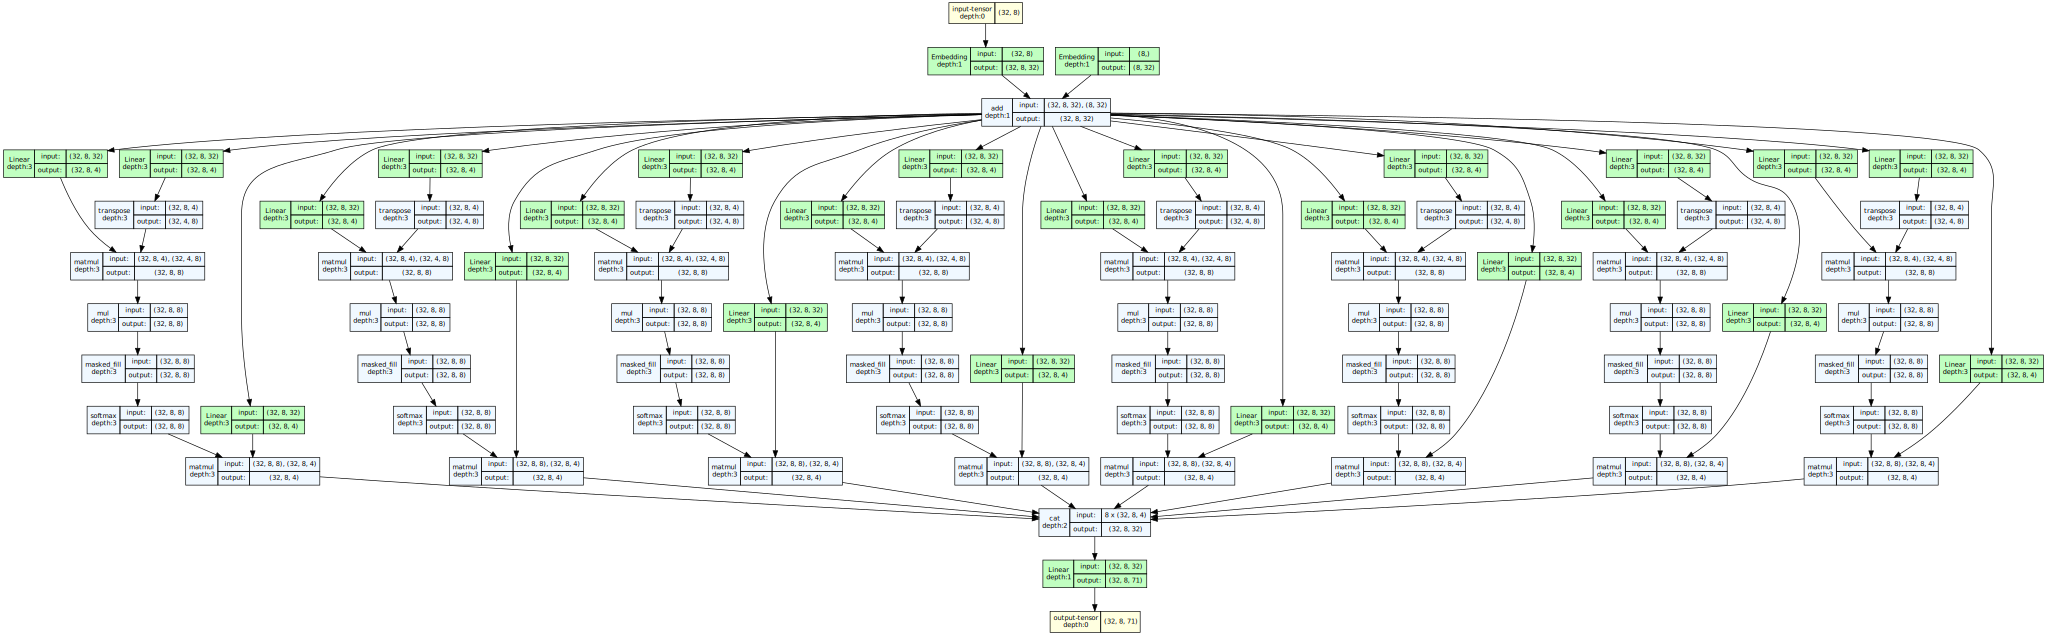

In [29]:
from torchview import draw_graph

model_graph = draw_graph(
    BigramLanguageModel(vocab_size, emb_size),
    input_size=(batch_size, block_size),
    dtypes=[torch.long]
)
model_graph.visual_graph

## 11. Sanity check: untrained generation

## 8. Self-attention — what's new

This is the core idea of the transformer. For every token we compute three vectors:

- **query**: "what am I looking for?"
- **key**: "what do I contain?"
- **value**: "what do I communicate if attended to?" (if there is a match for query and key, what will I send as an output)

We score every query against every key (`query @ key^T`) to get raw attention scores, scale by `sqrt(head_size)` to keep the softmax well-behaved, **mask out future positions** with a lower-triangular mask (`tril`) so a token can only attend to itself and earlier tokens, softmax the scores into a probability distribution (`weights`), and finally take a weighted sum of the `value` vectors.

**In class:** fill in the parts marked **NEW** below.

In [15]:
model = BigramLanguageModel(vocab_size, emb_size)
model = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

0.007943 M parameters
 cz6t!7B8QmW□yCO2BmS4~E■A‘XjT~cWQZQ•p6Bj3‘o7xbrI3tzGxYp‘lWDO4M?R6wJkQoNvhrBALHvHSO0Xpqf5QoOr?osOt5VFHb~Dx63dJdcLuxQc0ODHWGl1mfDBEh5iMor‘a1gogZ1lTZoCGEft3kYzNLEforGEs•l7bSJ8i4G~BTdiMgcE■vSv4NravtNnDghbd


## 12. Training the model

In [16]:
# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iters):

    # every once in a while evaluate the loss on train and val sets
    if iter % eval_interval == 0 or iter == max_iters - 1:
        losses = estimate_loss()
        print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")

    # sample a batch of data
    xb, yb = get_batch('train')

    # evaluate the loss
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

step 0: train loss 4.3047, val loss 4.3098
step 500: train loss 2.4915, val loss 2.4874
step 1000: train loss 2.3884, val loss 2.3643
step 1500: train loss 2.3270, val loss 2.3014
step 2000: train loss 2.2707, val loss 2.2441
step 2500: train loss 2.2436, val loss 2.2237
step 3000: train loss 2.2195, val loss 2.1916
step 3500: train loss 2.1942, val loss 2.1904
step 4000: train loss 2.1776, val loss 2.1544
step 4500: train loss 2.1748, val loss 2.1522
step 5000: train loss 2.1515, val loss 2.1359
step 5500: train loss 2.1499, val loss 2.1323
step 6000: train loss 2.1236, val loss 2.1110
step 6500: train loss 2.1186, val loss 2.1009
step 7000: train loss 2.1117, val loss 2.0932
step 7500: train loss 2.1065, val loss 2.0841
step 8000: train loss 2.0901, val loss 2.0815
step 8500: train loss 2.0918, val loss 2.0781
step 9000: train loss 2.0793, val loss 2.0756
step 9500: train loss 2.0786, val loss 2.0611
step 9999: train loss 2.0718, val loss 2.0602


*we've gotten

## 13. Generate text from the trained model

In [22]:
print('''\n##########################################
# Let's generate some Harry Potter text! #
##########################################''')
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(model.generate(context, max_new_tokens=2000)[0].tolist()))


##########################################
# Let's generate some Harry Potter text! #
##########################################
 med appionty .Yeprinild trell awis thirlloy lumbed Ron ker andmen .Dow to doulloy the aid the net rel Find it and An manckould ofelld sigefirning is .ty Harry .Ther poorzen shaid I I then and tha meted emilme dearund Fly thice feaver Uven oleded his therrmsaid bough largo de wrearrmy onfect ow shad burreed Harry waytacat .Hen the I whe Crormenas any livers sizers ank mat Harry daill anded to upresled were to thourgeal an of jurm andif of .sts air stound oken .Furied to helly athet cringlepen friten toan reall you nowiou .He cea den wald gilded ea him It reving eeave wouspuch renn .Youbleingotherce furbey .aby woped hit ?don ashos tho ?said Harrmbled youm fecamble Harry swain him Cake nerminbocke deent felld on bodera suosaid is al agring the af ther stelpled Hery amy .Nwhe mist bet he be then was and Mided toilles grain to histly to agight ther wiled wrad y

*now we have words longer than 2 or 3 characters and also some names like Harry*